In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit


ابعاد داده‌های خوانده‌شده: (300, 13)
ستون‌های موجود: ['Timestamp', 'Shift', 'Mean', 'LSL', 'USL', 'Moisture_Pct', 'Bentonite_Pct', 'Wet_Strength_N', 'Drop_Number', 'Target_Size_Pct', 'Fines_Pct', 'Oversize_Pct', 'Moisture_Status']

=== خلاصه‌سازی آماری متغیرها ===
                 count    mean    std    min     25%     50%     75%    max
Moisture_Pct     300.0   9.096  0.470   8.19   8.740   8.990   9.402  10.43
Bentonite_Pct    300.0   0.852  0.030   0.77   0.830   0.850   0.870   0.93
Wet_Strength_N   300.0  19.993  1.916  13.43  19.105  20.570  21.452  22.79
Drop_Number      300.0   5.407  0.690   4.00   5.000   5.000   6.000   7.00
Target_Size_Pct  300.0  77.029  4.889  60.00  76.220  78.380  79.958  84.79
Fines_Pct        300.0  11.813  2.841   7.31  10.135  11.095  12.558  25.82

=== تعداد مقادیر مفقوده (Missing Values) ===
Moisture_Pct       0
Bentonite_Pct      0
Wet_Strength_N     0
Drop_Number        0
Target_Size_Pct    0
Fines_Pct          0
dtype: int64


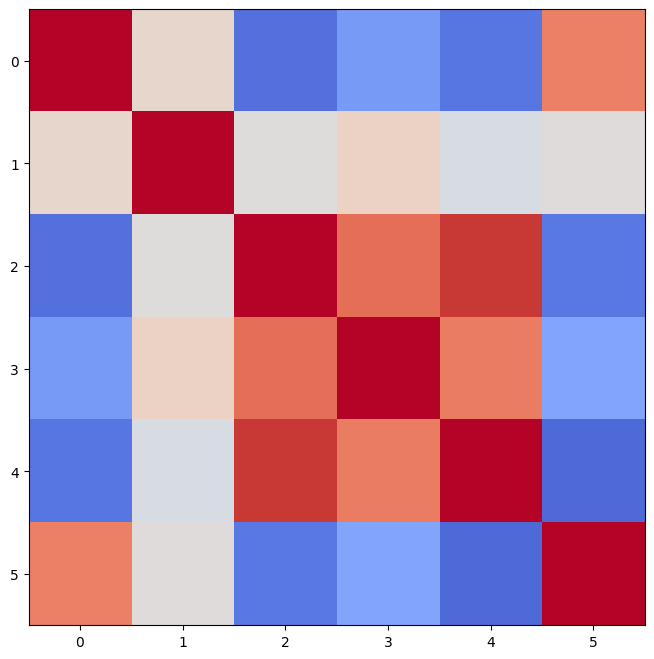

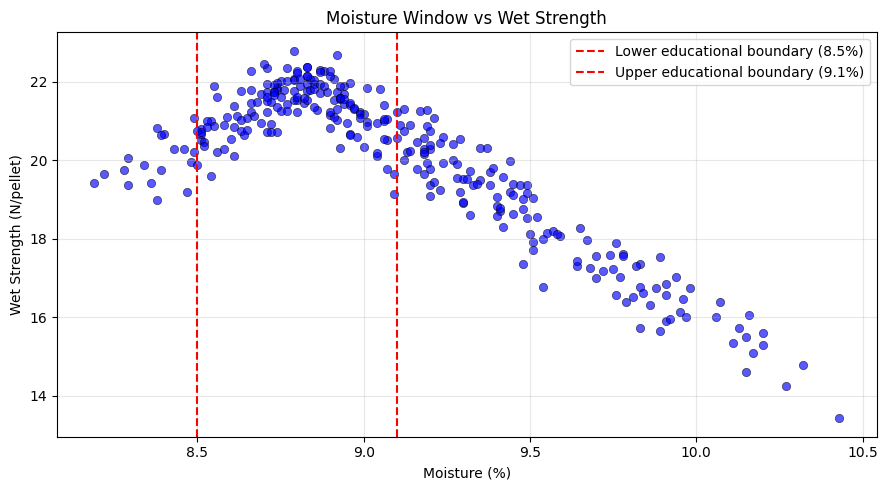


=== ضرایب مدل غیرخطی (Quadratic Model Coefficients) ===
b0 (Intercept) = -207.5352
b1 (Linear)    = 52.7014
b2 (Quadratic) = -3.0358


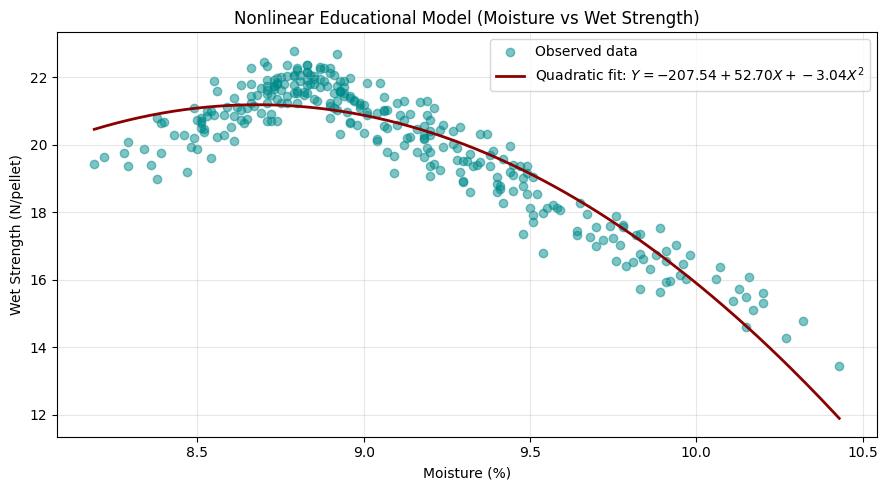

=== بررسی داده‌های پرت (Outliers) ===
🔹 ستون Moisture_Pct     | تعداد پرت: 1   | بازه مجاز: [7.75, 10.40]
🔹 ستون Bentonite_Pct    | تعداد پرت: 0   | بازه مجاز: [0.77, 0.93]
🔹 ستون Wet_Strength_N   | تعداد پرت: 8   | بازه مجاز: [15.58, 24.97]
🔹 ستون Drop_Number      | تعداد پرت: 0   | بازه مجاز: [3.50, 7.50]
🔹 ستون Target_Size_Pct  | تعداد پرت: 34  | بازه مجاز: [70.61, 85.56]
🔹 ستون Fines_Pct        | تعداد پرت: 24  | بازه مجاز: [6.50, 16.19]


In [12]:

# ۱. بارگذاری و کنترل اولیه داده‌ها
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

# ۱. بارگذاری شیت اصلی داده‌های خام (Sheet1)
file_path = "/home/qc/Green_Pellet_QC_Training_Data4.xlsx"
df = pd.read_excel(file_path, sheet_name="Sheet1")

# حذف فاصله‌های احتمالی نام ستون‌ها
df.columns = df.columns.str.strip()

print(f"ابعاد داده‌های خوانده‌شده: {df.shape}")
print(f"ستون‌های موجود: {df.columns.tolist()}\n")

# ستون‌های تحلیلی موجود در دیتاست
required_cols = [
    "Moisture_Pct",
    "Bentonite_Pct",
    "Wet_Strength_N",
    "Drop_Number",
    "Target_Size_Pct",
    "Fines_Pct",
]

missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing columns: {missing_cols}")

print("=== خلاصه‌سازی آماری متغیرها ===")
print(df[required_cols].describe().round(3).T)

print("\n=== تعداد مقادیر مفقوده (Missing Values) ===")
print(df[required_cols].isna().sum())


# ۲. ماتریس همبستگی پیرسون (Pearson Correlation Matrix) - نسخه اصلاح شده
# ستون Dry_Strength_N را حذف کردیم چون در فایل فعلی وجود ندارد
corr_cols = [
    "Moisture_Pct",
    "Bentonite_Pct",
    "Wet_Strength_N",
    "Drop_Number",
    "Target_Size_Pct",
    "Fines_Pct",
]

# بررسی اینکه آیا ستون‌ها واقعاً در دیتافریم هستند (یک چک‌لیست حرفه‌ای)
available_cols = [c for c in corr_cols if c in df.columns]
missing_in_df = [c for c in corr_cols if c not in df.columns]

if missing_in_df:
    print(f"هشدار: این ستون‌ها در فایل نیستند و حذف شدند: {missing_in_df}")

corr = df[available_cols].corr(method="pearson")

# ادامه رسم نمودار...
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap="coolwarm")
# ... (بقیه کدهای رسم نمودار)


# ۳. بررسی پنجره آموزشی رطوبت (Moisture Operating Window)
lower_moisture = 8.5
upper_moisture = 9.1

plt.figure(figsize=(9, 5))
plt.scatter(
df["Moisture_Pct"],
df["Wet_Strength_N"],
alpha=0.65,
c="blue",
edgecolors="k",
linewidths=0.5,
)

plt.axvline(
lower_moisture,
color="red",
linestyle="--",
linewidth=1.5,
label="Lower educational boundary (8.5%)",
)
plt.axvline(
upper_moisture,
color="red",
linestyle="--",
linewidth=1.5,
label="Upper educational boundary (9.1%)",
)

plt.xlabel("Moisture (%)")
plt.ylabel("Wet Strength (N/pellet)")
plt.title("Moisture Window vs Wet Strength", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig("moisture_window.png", dpi=200)
plt.show()

# نکته: این نمودار برای بررسی رفتار داده‌ها در اطراف پنجره آموزشی است و نباید به‌تنهایی برای تعیین optimum عملیاتی کارخانه استفاده شود.


# ۴. برازش مدل غیرخطی آموزشی (Quadratic Fitting)
# مدل درجه دوم برای رابطه رطوبت و استحکام تر:
# $$ W = \beta_0 + \beta_1 M + \beta_2 M^2 $$

model_df = df[["Moisture_Pct", "Wet_Strength_N"]].dropna()
x = model_df["Moisture_Pct"].to_numpy()
y = model_df["Wet_Strength_N"].to_numpy()


def quadratic_model(x, b0, b1, b2):
    return b0 + b1 * x + b2 * (x**2)


params, covariance = curve_fit(quadratic_model, x, y)
b0, b1, b2 = params

print("\n=== ضرایب مدل غیرخطی (Quadratic Model Coefficients) ===")
print(f"b0 (Intercept) = {b0:.4f}")
print(f"b1 (Linear)    = {b1:.4f}")
print(f"b2 (Quadratic) = {b2:.4f}")

x_fit = np.linspace(x.min(), x.max(), 200)
y_fit = quadratic_model(x_fit, *params)

plt.figure(figsize=(9, 5))
plt.scatter(x, y, alpha=0.5, label="Observed data", color="darkcyan")
plt.plot(
x_fit,
y_fit,
color="darkred",
linewidth=2,
label=f"Quadratic fit: $Y = {b0:.2f} + {b1:.2f}X + {b2:.2f}X^2$",
)

plt.xlabel("Moisture (%)")
plt.ylabel("Wet Strength (N/pellet)")
plt.title("Nonlinear Educational Model (Moisture vs Wet Strength)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig("moisture_nonlinear_model.png", dpi=200)
plt.show()


# ۵. بررسی داده‌های غیرعادی (Outlier Detection via IQR Method)
# . شناسایی داده‌های پرت (IQR Method) - نسخه پاکسازی‌شده
numeric_cols = [
    "Moisture_Pct",
    "Bentonite_Pct",
    "Wet_Strength_N",
    "Drop_Number",
    "Target_Size_Pct",
    "Fines_Pct",
]

# فقط ستون‌هایی که در شیت وجود دارند بررسی شوند
valid_numeric_cols = [col for col in numeric_cols if col in df.columns]

print("=== بررسی داده‌های پرت (Outliers) ===")
outliers_summary = {}

for col in valid_numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outliers_summary[col] = len(outliers)
    print(f"🔹 ستون {col:<16} | تعداد پرت: {len(outliers):<3} | بازه مجاز: [{lower_bound:.2f}, {upper_bound:.2f}]")

# نکته کنترل کیفیت: Outlier آماری الزاماً خطای داده نیست. قبل از حذف، علت فرآیندی، شرایط عملیاتی، خرابی تجهیز یا خطای اندازه‌گیری بررسی شود.
